In [1]:
import json 
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch 

In [ ]:
#load local data from open-data statsbomb
#world cup 2022
file_path = r'C:\Users\muham\授業\TBAFootballDataAnalyst\rjp_soccer\open-data\data\matches\43\106.json'
with open(file_path, encoding='utf-8') as file:
    data = json.load(file)
    
#convert to dataframe
# sep parameter to flatten nested structures
df =pd.json_normalize(data, sep="_") 

#checking the dataframe
print(f"Total Events:{len(df)}")
df.head()

Total Events:64


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,3857256,2022-12-02,21:00:00.000,2,3,available,available,2023-02-17T23:45:15.306706,2023-04-26T23:49:58.956186,3,...,10,Group Stage,1001115,Stadium 974,185,Qatar,1121.0,Fernando Andrés Rapallini,11.0,Argentina
1,3869151,2022-12-03,21:00:00.000,2,1,available,available,2023-07-30T07:46:05.382784,2023-07-30T07:48:51.865595,4,...,33,Round of 16,1000793,Ahmad bin Ali Stadium,185,Qatar,367.0,Szymon Marciniak,182.0,Poland
2,3857257,2022-11-30,17:00:00.000,1,0,available,available,2023-04-28T17:13:10.958725,2023-06-20T11:04:37.638969,3,...,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,2311.0,Mustapha Ghorbal,4.0,Algeria
3,3857258,2022-11-24,21:00:00.000,2,0,available,available,2023-06-24T17:17:27.911026,2023-07-11T14:56:31.096588,1,...,10,Group Stage,1001114,Lusail Stadium,185,Qatar,741.0,Alireza Faghani,107.0,"Iran, Islamic Republic of"
4,3857288,2022-11-26,12:00:00.000,0,1,available,available,2023-02-28T21:25:20.888552,2023-04-27T00:30:07.835815,2,...,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,225.0,Daniel Siebert,85.0,Germany


In [4]:
#checking columns
df.columns.to_list()

['match_id',
 'match_date',
 'kick_off',
 'home_score',
 'away_score',
 'match_status',
 'match_status_360',
 'last_updated',
 'last_updated_360',
 'match_week',
 'competition_competition_id',
 'competition_country_name',
 'competition_competition_name',
 'season_season_id',
 'season_season_name',
 'home_team_home_team_id',
 'home_team_home_team_name',
 'home_team_home_team_gender',
 'home_team_home_team_group',
 'home_team_country_id',
 'home_team_country_name',
 'home_team_managers',
 'away_team_away_team_id',
 'away_team_away_team_name',
 'away_team_away_team_gender',
 'away_team_away_team_group',
 'away_team_country_id',
 'away_team_country_name',
 'away_team_managers',
 'metadata_data_version',
 'metadata_shot_fidelity_version',
 'metadata_xy_fidelity_version',
 'competition_stage_id',
 'competition_stage_name',
 'stadium_id',
 'stadium_name',
 'stadium_country_id',
 'stadium_country_name',
 'referee_id',
 'referee_name',
 'referee_country_id',
 'referee_country_name']

In [7]:
#searching japan team match id 
match_japan = df[(df['home_team_home_team_name']=='Japan')|
              (df['away_team_away_team_name']== 'Japan')]

#displaying japan match info
info_japan = match_japan[['match_id','match_date','home_team_home_team_name','away_team_away_team_name', 'home_score', 'away_score']]

print('japan match info:')
print(info_japan)

japan match info:
    match_id  match_date home_team_home_team_name away_team_away_team_name  \
24   3869219  2022-12-05                    Japan                  Croatia   
31   3857295  2022-11-27                    Japan               Costa Rica   
33   3857284  2022-11-23                  Germany                    Japan   
62   3857255  2022-12-01                    Japan                    Spain   

    home_score  away_score  
24           1           1  
31           0           1  
33           1           2  
62           2           1  


In [11]:
#take a match file from info in japan match
#japan vs spain 
event_path = 'C:\\Users\\muham\\授業\\TBAFootballDataAnalyst\\rjp_soccer\\open-data\\data\\events\\3857255.json'
with open(event_path, encoding='utf-8') as file:
    data_match = json.load(file)
df_events = pd.json_normalize(data_match,sep='_')
df_events.columns.to_list()

['id',
 'index',
 'period',
 'timestamp',
 'minute',
 'second',
 'possession',
 'duration',
 'type_id',
 'type_name',
 'possession_team_id',
 'possession_team_name',
 'play_pattern_id',
 'play_pattern_name',
 'team_id',
 'team_name',
 'tactics_formation',
 'tactics_lineup',
 'related_events',
 'location',
 'player_id',
 'player_name',
 'position_id',
 'position_name',
 'pass_recipient_id',
 'pass_recipient_name',
 'pass_length',
 'pass_angle',
 'pass_height_id',
 'pass_height_name',
 'pass_end_location',
 'pass_body_part_id',
 'pass_body_part_name',
 'pass_type_id',
 'pass_type_name',
 'carry_end_location',
 'pass_outcome_id',
 'pass_outcome_name',
 'ball_receipt_outcome_id',
 'ball_receipt_outcome_name',
 'out',
 'under_pressure',
 'clearance_head',
 'clearance_body_part_id',
 'clearance_body_part_name',
 'off_camera',
 'pass_switch',
 'dribble_outcome_id',
 'dribble_outcome_name',
 'duel_type_id',
 'duel_type_name',
 'duel_outcome_id',
 'duel_outcome_name',
 'pass_cross',
 'pass_aeri

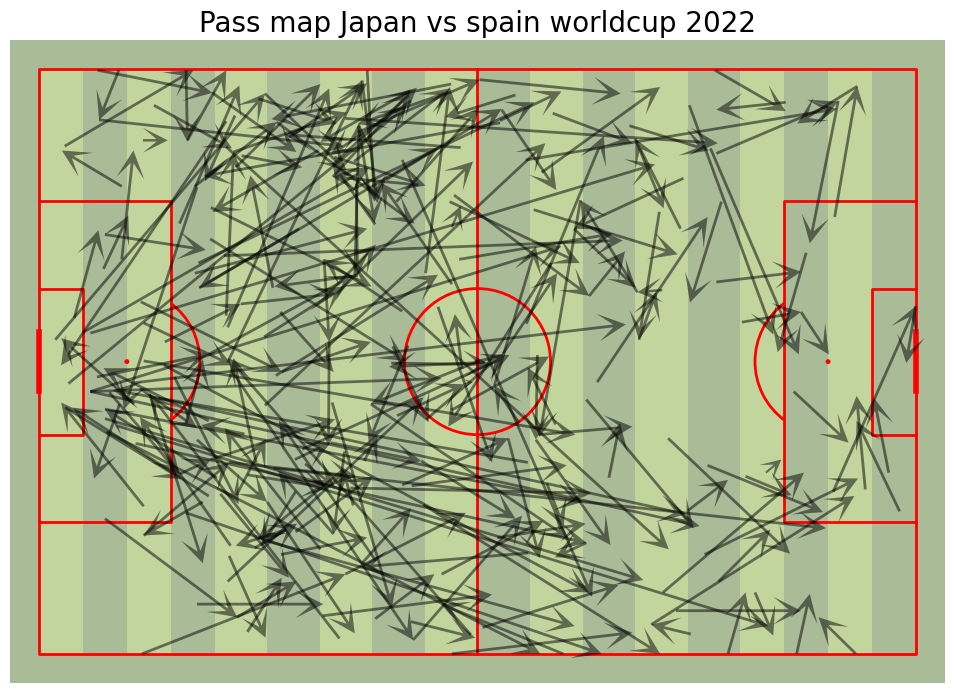

In [15]:
#Japan pass map vs spain
name_team = 'Japan'
df_pass = df_events[(df_events['type_name']=='Pass')&
                    (df_events['team_name']== name_team)].copy()

#take coordinates x and y from column location
df_pass['x'] = df_pass['location'].apply(lambda loc:loc[0]if isinstance(loc,list)else None)
df_pass['y'] = df_pass['location'].apply(lambda loc:loc[1]if isinstance(loc,list)else None)
df_pass['end_x'] = df_pass['pass_end_location'].apply(lambda loc:loc[0]if isinstance(loc,list)else None)
df_pass['end_y'] = df_pass['pass_end_location'].apply(lambda loc:loc[1]if isinstance(loc,list)else None)

#change to decimal format
df_pass['x']= df_pass['x'].astype(float)
df_pass['y']= df_pass['y'].astype(float)
df_pass['end_x']= df_pass['end_x'].astype(float)
df_pass['end_y']= df_pass['end_y'].astype(float)

#plotting pass map
pitch = Pitch(pitch_type='statsbomb',pitch_color="#aabb97",
              line_color='red',stripe=True)
fig, ax = pitch.draw(figsize=(10,7))

pitch.arrows(df_pass.x,df_pass.y,
             df_pass.end_x,df_pass.end_y,
             width=2,headwidth=10,headlength=10,
             color='black',ax=ax,label='Passes',alpha=0.5)

plt.title(f'Pass map {name_team} vs spain worldcup 2022',fontsize=20)
plt.show()




In [16]:
#check player names who made passes in japan team
print(df_pass['player_name'].unique())

['Junya Ito' 'Takefusa Kubo' 'Hidemasa Morita' 'Daichi Kamada' 'Ao Tanaka'
 'Ko Itakura' 'Maya Yoshida' 'Yuto Nagatomo' 'Shogo Taniguchi'
 'Shūichi Gonda' 'Daizen Maeda' 'Kaoru Mitoma' 'Ritsu Doan' 'Takuma Asano'
 'Takehiro Tomiyasu' 'Wataru Endo']


Statistics Ao Tanaka:
Total Passes:29
succesfull Passes:20
accuracy:69.0


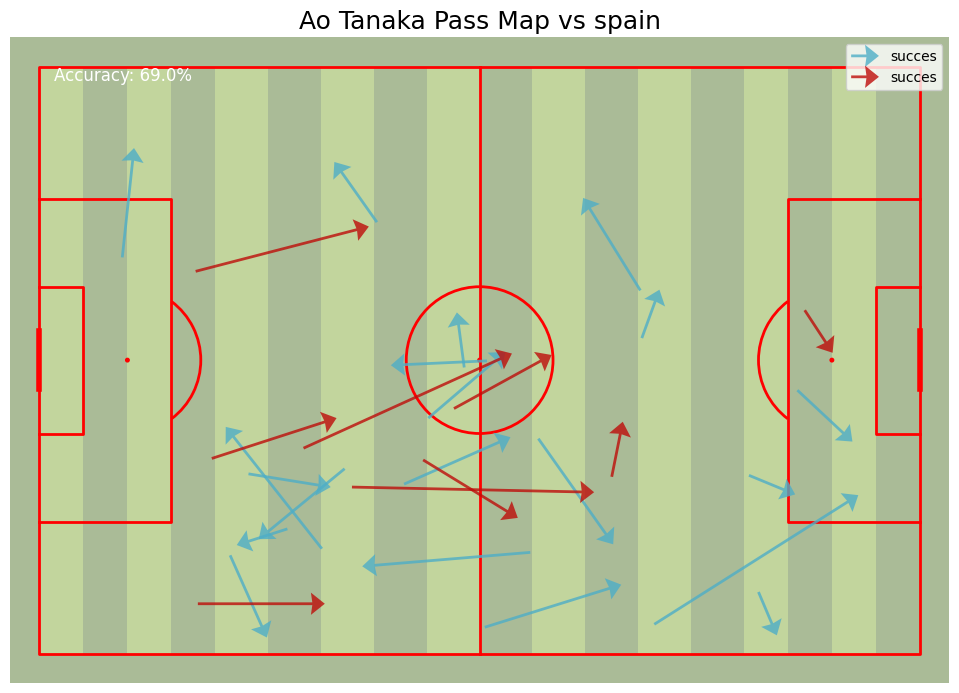

In [24]:
#target player : Ao Tanaka
target_player = 'Ao Tanaka'
player_pass = df_pass[df_pass['player_name']== target_player].copy()

#count total passes
#in stasbomb data if pass_outcome_name is missing means succesfull pass
total_passes = len(player_pass)
succesfull_passes = len(player_pass[player_pass['pass_outcome_name'].isna()])
accuracy = (succesfull_passes/total_passes)*100

print(f'Statistics {target_player}:')
print(f'Total Passes:{total_passes}')
print(f'succesfull Passes:{succesfull_passes}')
print(f'accuracy:{accuracy:.1f}')

#pitch plot for wataru endo passes
pitch = Pitch(pitch_type='statsbomb',pitch_color="#aabb97",
              line_color='red',stripe=True)
fig, ax = pitch.draw(figsize=(10,7))

succes = player_pass[player_pass['pass_outcome_name'].isna()]
pitch.arrows(succes.x,succes.y,succes.end_x,succes.end_y,
             width=2, headwidth=8, color='#4eaec7', ax=ax, label='succes', alpha=0.8)

unsucces = player_pass[player_pass['pass_outcome_name'].notna()]
pitch.arrows(unsucces.x,unsucces.y,unsucces.end_x,unsucces.end_y,
             width=2, headwidth=8, color="#be0d0a", ax=ax, label='succes', alpha=0.8)

ax.set_title(f'{target_player} Pass Map vs spain',fontsize=18,color='black')
ax.text(2, 2, f'Accuracy: {accuracy:.1f}%', color='white', fontsize=12)

plt.legend()
plt.show()


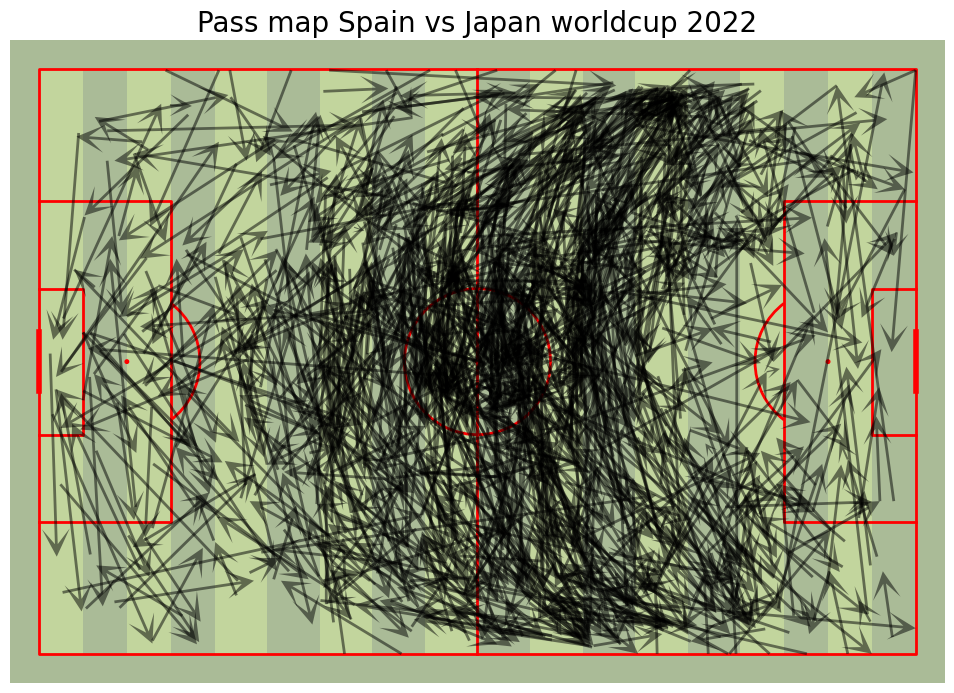

In [25]:
#spain pass map vs japan
name_team = 'Spain'
df_pass = df_events[(df_events['type_name']=='Pass')&
                    (df_events['team_name']== name_team)].copy()

#take coordinates x and y from column location
df_pass['x'] = df_pass['location'].apply(lambda loc:loc[0]if isinstance(loc,list)else None)
df_pass['y'] = df_pass['location'].apply(lambda loc:loc[1]if isinstance(loc,list)else None)
df_pass['end_x'] = df_pass['pass_end_location'].apply(lambda loc:loc[0]if isinstance(loc,list)else None)
df_pass['end_y'] = df_pass['pass_end_location'].apply(lambda loc:loc[1]if isinstance(loc,list)else None)

#change to decimal format
df_pass['x']= df_pass['x'].astype(float)
df_pass['y']= df_pass['y'].astype(float)
df_pass['end_x']= df_pass['end_x'].astype(float)
df_pass['end_y']= df_pass['end_y'].astype(float)

#plotting pass map
pitch = Pitch(pitch_type='statsbomb',pitch_color="#aabb97",
              line_color='red',stripe=True)
fig, ax = pitch.draw(figsize=(10,7))

pitch.arrows(df_pass.x,df_pass.y,
             df_pass.end_x,df_pass.end_y,
             width=2,headwidth=10,headlength=10,
             color='black',ax=ax,label='Passes',alpha=0.5)

plt.title(f'Pass map {name_team} vs Japan worldcup 2022',fontsize=20)
plt.show()




In [26]:
#check player names who made passes in spain team
print(df_pass['player_name'].unique())

['Pablo Martín Páez Gavira' 'Pau Francisco Torres'
 'César Azpilicueta Tanco' 'Rodrigo Hernández Cascante'
 'Pedro González López' 'Sergio Busquets i Burgos'
 'Álvaro Borja Morata Martín' 'Alejandro Balde Martínez'
 'Nicholas Williams Arthuer' 'Daniel Olmo Carvajal' 'Unai Simón Mendibil'
 'Daniel Carvajal Ramos' 'Ferrán Torres García' 'Marco Asensio Willemsen'
 'Jordi Alba Ramos' 'Anssumane Fati']


Statistics Sergio Busquets i Burgos:
Total Passes:74
succesfull Passes:69
accuracy:93.2


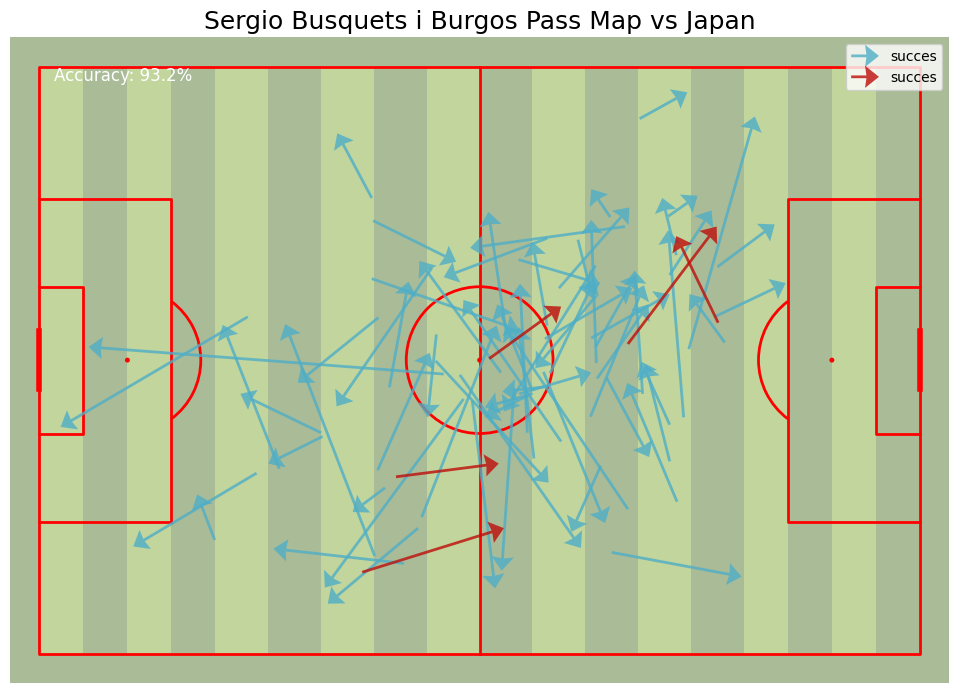

In [28]:
#target player : Sergio Busquets i Burgos
target_player = 'Sergio Busquets i Burgos'
player_pass = df_pass[df_pass['player_name']== target_player].copy()

#count total passes
#in stasbomb data if pass_outcome_name is missing means succesfull pass
total_passes = len(player_pass)
succesfull_passes = len(player_pass[player_pass['pass_outcome_name'].isna()])
accuracy = (succesfull_passes/total_passes)*100

print(f'Statistics {target_player}:')
print(f'Total Passes:{total_passes}')
print(f'succesfull Passes:{succesfull_passes}')
print(f'accuracy:{accuracy:.1f}')

#pitch plot for wataru endo passes
pitch = Pitch(pitch_type='statsbomb',pitch_color="#aabb97",
              line_color='red',stripe=True)
fig, ax = pitch.draw(figsize=(10,7))

succes = player_pass[player_pass['pass_outcome_name'].isna()]
pitch.arrows(succes.x,succes.y,succes.end_x,succes.end_y,
             width=2, headwidth=8, color='#4eaec7', ax=ax, label='succes', alpha=0.8)

unsucces = player_pass[player_pass['pass_outcome_name'].notna()]
pitch.arrows(unsucces.x,unsucces.y,unsucces.end_x,unsucces.end_y,
             width=2, headwidth=8, color="#be0d0a", ax=ax, label='succes', alpha=0.8)

ax.set_title(f'{target_player} Pass Map vs Japan',fontsize=18,color='black')
ax.text(2, 2, f'Accuracy: {accuracy:.1f}%', color='white', fontsize=12)

plt.legend()
plt.show()


In [ ]:
#pass network analysis
team_name = 'Spain'

#take data only before subs
subs = df_events[
    (df_events['type_name']== 'Substitution')&
    (df_events['team_name']== team_name)
]

#get time od the first sub
first_sub_minute = subs['minute'].min() if not subs.empty else 90
print(f'Analyzing pass network before minute {first_sub_minute}')

